# Dermoscopic Lesion Classification Using Vision Transformers
### ViT-B/16 vs MobileNetV3-Large on ISIC Archive 2019 — 

**Dataset:** ISIC Archive 2019 — 25,331 dermoscopic images, 8 classes  
**Models:** ViT-B/16 (primary) vs MobileNetV3-Large (baseline)  
**Metrics:** Accuracy, Precision, Recall, F1 (macro + per-class), Balanced Accuracy, AUC-ROC, Confusion Matrix  
**Runs in:** Jupyter Notebook (local) — Python 3.8+ with GPU recommended  

---
**Setup steps:**
1. Run **Cell 1** to install packages
2. Set `DATA_DIR` in **Cell 3** to your local ISIC 2019 folder 
3. Run all cells top to bottom — **Kernel → Restart & Run All**

> Dataset download: https://www.kaggle.com/datasets/andrewmvd/isic-2019

In [1]:
# Cell 1 — Install Dependencies 
import subprocess, sys

packages = ['timm', 'torch', 'torchvision', 'pandas', 'numpy',
            'matplotlib', 'seaborn', 'scikit-learn', 'Pillow', 'tqdm']

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\nAll packages installed successfully!')

Installing timm...
Installing torch...
Installing torchvision...
Installing pandas...
Installing numpy...
Installing matplotlib...
Installing seaborn...
Installing scikit-learn...
Installing Pillow...
Installing tqdm...

All packages installed successfully!


In [2]:
# Cell 2 — Import Libraries

import os, sys, json, random, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc, balanced_accuracy_score, f1_score,
    precision_score, recall_score, accuracy_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Using device    : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch version : 2.5.1+cu121
Using device    : cuda
GPU             : NVIDIA RTX 5000 Ada Generation
GPU memory      : 34.4 GB


In [3]:
# Cell 3 — Dataset Setup
DATA_DIR  = 'C:/Users/1551309/isic-2019'
IMAGE_DIR = os.path.join(DATA_DIR, 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
META_CSV  = os.path.join(DATA_DIR, 'ISIC_2019_Training_GroundTruth.csv')

errors = []
if not os.path.isdir(DATA_DIR):   errors.append(f'DATA_DIR not found: {DATA_DIR}')
if not os.path.isdir(IMAGE_DIR):  errors.append(f'IMAGE_DIR not found: {IMAGE_DIR}')
if not os.path.isfile(META_CSV):  errors.append(f'META_CSV not found: {META_CSV}')

if errors:
    for e in errors: print(e)
else:
    img_count = len([f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg','.jpeg','.png'))])
    print(f'Images found: {img_count:,}')

Images found: 25,331


In [4]:
# Cell 4 — Load Labels for each class and process
gt_df = pd.read_csv(META_CSV)

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
CLASS_FULL  = [
    'Melanoma', 'Melanocytic Nevi', 'Basal Cell Carcinoma',
    'Actinic Keratosis', 'Benign Keratosis', 'Dermatofibroma',
    'Vascular Lesion', 'Squamous Cell Carcinoma',
]
NUM_CLASSES = len(CLASS_NAMES)

gt_df['label']      = gt_df[CLASS_NAMES].values.argmax(axis=1)
gt_df['class_name'] = gt_df['label'].map(lambda i: CLASS_FULL[i])

def find_image_path(image_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        candidate = os.path.join(IMAGE_DIR, image_id + ext)
        if os.path.exists(candidate):
            return candidate
    return None

gt_df['image_path'] = gt_df['image'].apply(find_image_path)
gt_df = gt_df.dropna(subset=['image_path']).reset_index(drop=True)
print(f'Total usable images: {len(gt_df):,}')
print(gt_df['class_name'].value_counts().to_string())

Total usable images: 25,331
class_name
Melanocytic Nevi           12875
Melanoma                    4522
Basal Cell Carcinoma        3323
Benign Keratosis            2624
Actinic Keratosis            867
Squamous Cell Carcinoma      628
Vascular Lesion              253
Dermatofibroma               239


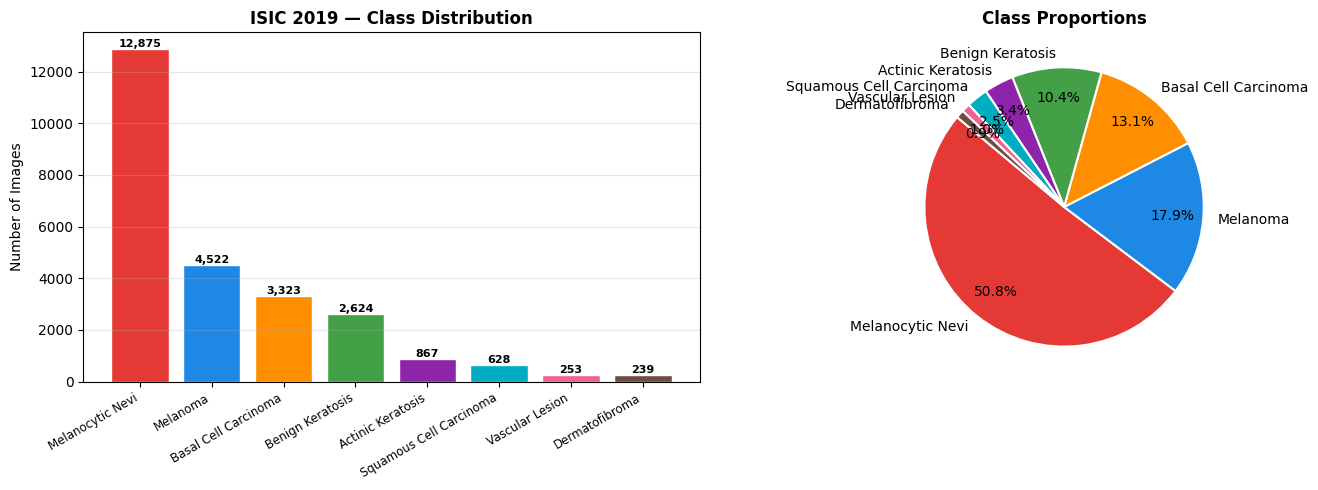

Imbalance ratio: 53.9:1


In [5]:
# Cell 5 — Exploratory Data Analysis (EDA): Class Distribution
# Calculate the count of each class in the ground truth DataFrame.
# Define a list of distinct colors for the visualization.

class_counts = gt_df['class_name'].value_counts()
colors = ['#E53935','#1E88E5','#FF8F00','#43A047','#8E24AA','#00ACC1','#F06292','#6D4C41']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
bars = axes[0].bar(range(len(class_counts)), class_counts.values, color=colors, edgecolor='white')
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_counts.index, rotation=30, ha='right', fontsize=8.5)
axes[0].set_title('ISIC 2019 — Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 80, f'{val:,}', ha='center', fontsize=8, fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.78,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportions', fontweight='bold')
plt.tight_layout()
plt.savefig('isic_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {class_counts.max()/class_counts.min():.1f}:1')

In [6]:
# Cell 6 — Train/Val/Test Split 
# Split the ground truth DataFrame into training and a temporary set (validation + test).
# The 'stratify' parameter ensures that the class distribution is maintained across splits.
# 'random_state' ensures reproducibility of the split.

train_df, temp_df = train_test_split(gt_df, test_size=0.30, stratify=gt_df['label'], random_state=SEED)

# Determine how to split the temporary dataset into validation and test sets.
# This check is crucial for handling cases where a class might have very few samples
# (less than 2) in the temporary set after the first split. If a class has only one sample,
# 'stratify' cannot be used for that class, so we fall back to a non-stratified split for
# the validation and test sets.
if temp_df['label'].value_counts().min() < 2:
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)
else:
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Training   : {len(train_df):,}')
print(f'Validation : {len(val_df):,}')
print(f'Test       : {len(test_df):,}')

Training   : 17,731
Validation : 3,800
Test       : 3,800


In [7]:
# Cell 7 — Image Transforms and Augmentation

# sets up how we prepare images for our neural network.
# We apply various transformations and augmentations (like flipping, rotating, and color changes)
# to training images to make the model more robust and prevent overfitting.
# For validation and testing, images are consistently resized and normalized.
# An additional transform (TTA) is defined for 'Test-Time Augmentation' to get more reliable predictions.


IMG_SIZE = 224
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.30, contrast=0.30,    # increased from 0.25
        saturation=0.30, hue=0.10          # increased from 0.25 / 0.08
    ),
    transforms.RandomGrayscale(p=0.05),    # NEW: slight colour invariance
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandAugment(num_ops=2, magnitude=9),  # NEW: AutoAugment-style policies
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.20)),  # NEW: occlusion robustness
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# NEW: TTA transforms — light augmentation applied multiple times at inference
tta_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Transforms defined.')
print('Training: H/V flip, rotation, stronger color jitter, RandomGrayscale, RandAugment, RandomErasing')
print('TTA: light flip + rotation for inference-time averaging')

Transforms defined.
Training: H/V flip, rotation, stronger color jitter, RandomGrayscale, RandAugment, RandomErasing
TTA: light flip + rotation for inference-time averaging


In [8]:
# Cell 8 — Custom Dataset and DataLoaders

# defines how model will 'see' and access the images.
# We create a custom `ISICDataset` class to tell PyTorch how to load
# each image and its corresponding label from our DataFrame.
# We also set up `DataLoader`s for training, validation, and testing.
# The training DataLoader includes a `WeightedRandomSampler` to help
# the model learn from all classes, especially the rare ones, by giving
# more importance to under-represented samples.

class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['image_path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label


def make_weighted_sampler(df):
    counts        = df['label'].value_counts().sort_index().values
    class_weights = 1.0 / counts
    sample_weights = [float(class_weights[lbl]) for lbl in df['label']]
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


train_dataset = ISICDataset(train_df, train_transform)
val_dataset   = ISICDataset(val_df,   eval_transform)
test_dataset  = ISICDataset(test_df,  eval_transform)

BATCH_SIZE  = 32
NUM_WORKERS = 0  # set to 2–4 on Linux/Mac

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=make_weighted_sampler(train_df),
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print(f'Batches per epoch — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches per epoch — Train: 555 | Val: 119 | Test: 119


In [9]:
# Cell 9 — Loss Function and Training Utilities

# Sets up how our model learns and improves its predictions. It defines:
# The 'loss function': How we measure if the model's prediction is wrong.
# 'Optimizers': How the model adjusts its internal settings to minimize the 'wrongness'.
# 'Schedulers': Tools to fine-tune the learning speed for better, more stable training.
# The main 'training and evaluation loops': The routines that teach the model and check its performance.

# Includes advanced techniques like adjusting for imbalanced data, preventing
# the model from bein confident, and carefully controlling the learning process to
# get the best possible results.


# ── Class-weighted cross-entropy with LABEL SMOOTHING ────────────────────────
full_label_counts = np.zeros(NUM_CLASSES)
current_label_counts = train_df['label'].value_counts().sort_index()
for label, count in current_label_counts.items():
    full_label_counts[label] = count

inverse_freq    = np.where(full_label_counts > 0, 1.0 / full_label_counts, 0.0)
sum_inv         = inverse_freq.sum()
class_weights   = torch.tensor(
    inverse_freq / sum_inv * NUM_CLASSES, dtype=torch.float
).to(DEVICE)

# CHANGE: label_smoothing=0.1 added
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

print('Loss: CrossEntropyLoss with class weights + label_smoothing=0.1')
print('Class weights (higher = penalised more for mistakes):')
for i, w in enumerate(class_weights.cpu().numpy()):
    print(f'  {CLASS_NAMES[i]:5s}: {w:.4f}')


# ── Cosine-with-warmup scheduler factory ─────────────────────────────────────
# proper warmup prevents early large gradient updates from damaging
# pretrained weights before the model has adapted to the new task
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ── Training function — now with gradient clipping ───────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler=None, clip_grad=1.0):
    model.train()
    total_loss = 0.0; correct = 0; total = 0

    for imgs, labels in tqdm(loader, desc='Training', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        # CHANGE: gradient clipping — essential for ViT with many parameters
        if clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


# ── Evaluation function ──────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0; correct = 0; total = 0
    all_preds = []; all_labels = []; all_probs = []

    for imgs, labels in tqdm(loader, desc='Evaluating', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs      = model(imgs)
        probs        = torch.softmax(outputs, dim=1)
        loss         = criterion(outputs, labels)
        total_loss  += loss.item() * imgs.size(0)
        correct     += (outputs.argmax(1) == labels).sum().item()
        total       += imgs.size(0)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (
        total_loss / total, correct / total,
        np.array(all_preds), np.array(all_labels), np.array(all_probs)
    )


# ── Full training loop — now saves by BALANCED ACCURACY ──────────────────────
def train_model(model, train_loader, val_loader,
                optimizer, scheduler, epochs, model_name, clip_grad=1.0):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    # CHANGE: track balanced accuracy for best-model checkpoint
    best_val_bal_acc = 0.0
    best_weights     = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scheduler, clip_grad)
        vl_loss, vl_acc, vl_preds, vl_true, _ = evaluate(model, val_loader)

        # CHANGE: compute balanced accuracy on validation set
        vl_bal_acc = balanced_accuracy_score(vl_true, vl_preds)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # CHANGE: save best by balanced accuracy instead of raw accuracy
        if vl_bal_acc > best_val_bal_acc:
            best_val_bal_acc = vl_bal_acc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f'[{model_name}] Ep {epoch:02d}/{epochs}  '
              f'TrLoss:{tr_loss:.4f} TrAcc:{tr_acc:.4f}  '
              f'VlLoss:{vl_loss:.4f} VlAcc:{vl_acc:.4f} VlBalAcc:{vl_bal_acc:.4f}')

    model.load_state_dict(best_weights)
    print(f'\nBest val balanced accuracy [{model_name}]: {best_val_bal_acc:.4f}')
    return model, history


print('Training utilities ready.')

Loss: CrossEntropyLoss with class weights + label_smoothing=0.1
Class weights (higher = penalised more for mistakes):
  MEL  : 0.1490
  NV   : 0.0523
  BCC  : 0.2028
  AK   : 0.7771
  BKL  : 0.2568
  DF   : 2.8247
  VASC : 2.6651
  SCC  : 1.0721
Training utilities ready.


In [10]:
# ── Load pretrained MobileNetV3-Large ─────────────────────────────────────────


#     Train it in two distinct phases to get the best performance:
#   - **Phase 1: Head-only Training:** We first train only the final classification layer
#     (the 'head') of the model. This allows the model to quickly learn how to map
#     the powerful features extracted by the pre-trained MobileNetV3 backbone to
#     our specific eight lesion classes, without altering the backbone itself.
#   - **Phase 2: Fine-tuning the Full Network:** After the head is warmed up, we
#     'unfreeze' all layers of the MobileNetV3 model and train the entire network
#     with a much smaller learning rate. This fine-tunes the pre-trained features
#     to be even more specific to our dermatoscopic images.
# This phased approach helps to achieve stable training and better accuracy,
# especially when working with pre-trained models on new datasets.

mobilenet = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
)

in_feat = mobilenet.classifier[3].in_features
mobilenet.classifier[3] = nn.Linear(in_feat, NUM_CLASSES)
mobilenet = mobilenet.to(DEVICE)

total_params = sum(p.numel() for p in mobilenet.parameters())
print(f'MobileNetV3 total parameters: {total_params:,}')

# ── Phase 1: train classifier head only (5 epochs) ───────────────────────────
# Freeze backbone so pretrained ImageNet features are preserved
print('\n--- Phase 1: Training classifier head only ---')
for param in mobilenet.features.parameters():
    param.requires_grad = False

trainable_p1 = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
print(f'Trainable parameters in Phase 1: {trainable_p1:,}')

opt1 = optim.AdamW(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=1e-3, weight_decay=1e-4
)
sch1 = optim.lr_scheduler.OneCycleLR(
    opt1, max_lr=1e-3,
    steps_per_epoch=len(train_loader), epochs=5
)

mobilenet, _ = train_model(
    mobilenet, train_loader, val_loader, opt1, sch1, 5, 'MobileNetV3-Phase1'
)

# ── Phase 2: unfreeze all layers and fine-tune (15 epochs) ───────────────────
# Use a much smaller learning rate to avoid overwriting pretrained features
print('\n--- Phase 2: Fine-tuning full network ---')
for param in mobilenet.parameters():
    param.requires_grad = True

opt2 = optim.AdamW(mobilenet.parameters(), lr=1e-4, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=10)

mobilenet, mob_history = train_model(
    mobilenet, train_loader, val_loader, opt2, sch2, 15, 'MobileNetV3-Phase2'
)

# Save weights to disk
torch.save(mobilenet.state_dict(), 'mobilenetv3_isic2019.pth')
print('\nModel saved: mobilenetv3_isic2019.pth')

MobileNetV3 total parameters: 4,212,280

--- Phase 1: Training classifier head only ---
Trainable parameters in Phase 1: 1,240,328


[MobileNetV3-Phase1] Ep 01/5  TrLoss:1.3181 TrAcc:0.2560  VlLoss:3.1220 VlAcc:0.0547 VlBalAcc:0.3073


[MobileNetV3-Phase1] Ep 02/5  TrLoss:1.1072 TrAcc:0.3353  VlLoss:2.8917 VlAcc:0.1455 VlBalAcc:0.4092


[MobileNetV3-Phase1] Ep 03/5  TrLoss:1.0184 TrAcc:0.3665  VlLoss:2.8923 VlAcc:0.1721 VlBalAcc:0.4526


[MobileNetV3-Phase1] Ep 04/5  TrLoss:0.9492 TrAcc:0.3955  VlLoss:2.8226 VlAcc:0.1718 VlBalAcc:0.4285


...

[MobileNetV3-Phase2] Ep 11/15  TrLoss:0.5570 TrAcc:0.6597  VlLoss:2.2351 VlAcc:0.4350 VlBalAcc:0.6598


[MobileNetV3-Phase2] Ep 12/15  TrLoss:0.5493 TrAcc:0.6724  VlLoss:2.1912 VlAcc:0.4684 VlBalAcc:0.6829


[MobileNetV3-Phase2] Ep 13/15  TrLoss:0.5300 TrAcc:0.6860  VlLoss:2.2041 VlAcc:0.5061 VlBalAcc:0.6902


[MobileNetV3-Phase2] Ep 14/15  TrLoss:0.5235 TrAcc:0.6995  VlLoss:2.1987 VlAcc:0.4442 VlBalAcc:0.6638


[MobileNetV3-Phase2] Ep 15/15  TrLoss:0.5203 TrAcc:0.7058  VlLoss:2.1814 VlAcc:0.4726 VlBalAcc:0.6729

Best val balanced accuracy [MobileNetV3-Phase2]: 0.6902

Model saved: mobilenetv3_isic2019.pth


In [11]:
# Cell 11 — Train ViT-B/16

#
#   1. LAYER-WISE LEARNING RATE DECAY (LLRD) — the single biggest improvement for ViT.
#      Early ViT blocks learn general image features that transfer across domains;
#      late blocks are task-specific. LLRD applies:
#        - head (classifier)     : base_lr = 2e-4
#        - block 11 (deepest)    : base_lr × 0.65^1
#        - block 10              : base_lr × 0.65^2
#        - ...                   : ...
#        - block 0 (shallowest)  : base_lr × 0.65^12
#        - patch_embed / cls_tok : base_lr × 0.65^13
#      This gives very low LR to general features and high LR to task-specific ones.
#      Expected gain: +1.5–3% accuracy vs uniform LR
#
#   2. UNFREEZE ALL BLOCKS in Phase 2
#      Combined with LLRD, earlier blocks get tiny LR — safe to unfreeze them all.
#      Freezing blocks 0–7 was leaving adaptation potential on the table.
#
#   3. COSINE WITH WARMUP scheduler in Phase 2
#      10% warmup steps prevent large gradient spikes at the start of fine-tuning.
#
#   4. Phase-2 epochs :30
#      ViT needs more time to adapt all 12 blocks with LLRD.
#
#   5. Gradient clipping (max_norm=1.0) — shared with MobileNet but more critical here
# ══════════════════════════════════════════════

IMG_SIZE = 224  # keep 224 so MobileNet and ViT share the same DataLoader

vit = timm.create_model(
    'vit_base_patch16_224',  # 224px — same as MobileNet, avoids separate DataLoader
    pretrained=True,
    num_classes=NUM_CLASSES
)
vit = vit.to(DEVICE)

print(f'ViT-B/16 total params: {sum(p.numel() for p in vit.parameters()):,}')


# ── Helper: build LLRD parameter groups for ViT ──────────────────────────────
def get_vit_llrd_param_groups(model, base_lr, weight_decay, layer_decay=0.65):
    """
    Layer-wise learning rate decay for ViT.
    Each block gets base_lr * layer_decay^(depth_from_head).
    No-decay params (bias, norm weights) skip weight_decay.
    """
    num_layers = len(model.blocks)   # 12 for ViT-B/16
    no_decay   = {'bias', 'norm', 'cls_token', 'pos_embed'}  # never decay these

    def is_no_decay(name):
        return any(nd in name for nd in no_decay)

    param_groups = []

    # 1. Head + final norm → full base_lr
    head_decay   = [p for n, p in model.named_parameters() if (n.startswith('head') or n.startswith('norm')) and not is_no_decay(n)]
    head_nodecay = [p for n, p in model.named_parameters() if (n.startswith('head') or n.startswith('norm')) and is_no_decay(n)]
    if head_decay:   param_groups.append({'params': head_decay,   'lr': base_lr, 'weight_decay': weight_decay})
    if head_nodecay: param_groups.append({'params': head_nodecay, 'lr': base_lr, 'weight_decay': 0.0})

    # 2. Transformer blocks — deeper = smaller decay factor applied
    for layer_idx in range(num_layers - 1, -1, -1):
        decay_factor = layer_decay ** (num_layers - layer_idx)
        lr_for_layer = base_lr * decay_factor

        blk_decay   = [p for n, p in model.named_parameters()
                       if f'blocks.{layer_idx}.' in n and not is_no_decay(n)]
        blk_nodecay = [p for n, p in model.named_parameters()
                       if f'blocks.{layer_idx}.' in n and is_no_decay(n)]
        if blk_decay:   param_groups.append({'params': blk_decay,   'lr': lr_for_layer, 'weight_decay': weight_decay})
        if blk_nodecay: param_groups.append({'params': blk_nodecay, 'lr': lr_for_layer, 'weight_decay': 0.0})

    # 3. Patch embed + cls_token + pos_embed — very small LR
    embed_lr    = base_lr * (layer_decay ** (num_layers + 1))
    embed_decay = [p for n, p in model.named_parameters()
                   if (n.startswith('patch_embed')) and not is_no_decay(n)]
    embed_nd    = [p for n, p in model.named_parameters()
                   if (n.startswith('patch_embed') or n in ('cls_token', 'pos_embed')) and is_no_decay(n)]
    if embed_decay: param_groups.append({'params': embed_decay, 'lr': embed_lr, 'weight_decay': weight_decay})
    if embed_nd:    param_groups.append({'params': embed_nd,    'lr': embed_lr, 'weight_decay': 0.0})

    return param_groups


# ── Phase 1: head only (6 epochs) — same as before ───────────────────────────
print('\n--- Phase 1: ViT head only (6 epochs) ---')
for name_p, param in vit.named_parameters():
    param.requires_grad = name_p.startswith('head')

opt_v1 = optim.AdamW(
    filter(lambda p: p.requires_grad, vit.parameters()),
    lr=3e-4, weight_decay=0.05
)
sch_v1 = optim.lr_scheduler.OneCycleLR(
    opt_v1, max_lr=3e-4, steps_per_epoch=len(train_loader), epochs=6
)

vit, _ = train_model(vit, train_loader, val_loader, opt_v1, sch_v1, 6, 'ViT-Ph1')


# ── Phase 2: ALL blocks + LLRD + cosine warmup (30 epochs) ───────────────────
print('\n--- Phase 2: ALL blocks with LLRD + cosine warmup (30 epochs) ---')

# CHANGE: unfreeze ALL parameters
for param in vit.parameters():
    param.requires_grad = True

# CHANGE: LLRD parameter groups with base_lr=2e-4, layer_decay=0.65
VIT_BASE_LR    = 2e-4
VIT_LAYER_DECAY = 0.65
param_groups   = get_vit_llrd_param_groups(vit, VIT_BASE_LR, weight_decay=0.05, layer_decay=VIT_LAYER_DECAY)
opt_v2         = optim.AdamW(param_groups)

# CHANGE: cosine schedule with 10% warmup
PHASE2_EPOCHS     = 30
total_steps       = PHASE2_EPOCHS * len(train_loader)
warmup_steps      = int(0.10 * total_steps)  # 10% warmup
sch_v2 = get_cosine_schedule_with_warmup(opt_v2, warmup_steps, total_steps)

print(f'LLRD: base_lr={VIT_BASE_LR}, layer_decay={VIT_LAYER_DECAY}')
print(f'Warmup: {warmup_steps} steps ({10}% of {total_steps} total)')
trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

vit, vit_history = train_model(
    vit, train_loader, val_loader, opt_v2, sch_v2, PHASE2_EPOCHS, 'ViT-Ph2'
)

torch.save(vit.state_dict(), 'vit_b16_isic2019.pth')
print('Saved: vit_b16_isic2019.pth')

ViT-B/16 total params: 85,804,808

--- Phase 1: ViT head only (6 epochs) ---


[ViT-Ph1] Ep 01/6  TrLoss:1.6128 TrAcc:0.1743  VlLoss:3.0958 VlAcc:0.0474 VlBalAcc:0.3141


[ViT-Ph1] Ep 02/6  TrLoss:1.1724 TrAcc:0.2964  VlLoss:2.8512 VlAcc:0.0932 VlBalAcc:0.3578


[ViT-Ph1] Ep 03/6  TrLoss:1.0986 TrAcc:0.3387  VlLoss:2.8557 VlAcc:0.1079 VlBalAcc:0.3853


[ViT-Ph1] Ep 04/6  TrLoss:1.0477 TrAcc:0.3616  VlLoss:2.8546 VlAcc:0.1218 VlBalAcc:0.3977


...

[ViT-Ph2] Ep 26/30  TrLoss:0.3804 TrAcc:0.9698  VlLoss:1.9182 VlAcc:0.8513 VlBalAcc:0.8118


[ViT-Ph2] Ep 27/30  TrLoss:0.3800 TrAcc:0.9684  VlLoss:1.9225 VlAcc:0.8474 VlBalAcc:0.8081


[ViT-Ph2] Ep 28/30  TrLoss:0.3739 TrAcc:0.9700  VlLoss:1.9180 VlAcc:0.8489 VlBalAcc:0.8120


[ViT-Ph2] Ep 29/30  TrLoss:0.3751 TrAcc:0.9698  VlLoss:1.9148 VlAcc:0.8511 VlBalAcc:0.8144


[ViT-Ph2] Ep 30/30  TrLoss:0.3751 TrAcc:0.9710  VlLoss:1.9151 VlAcc:0.8503 VlBalAcc:0.8143

Best val balanced accuracy [ViT-Ph2]: 0.8210
Saved: vit_b16_isic2019.pth


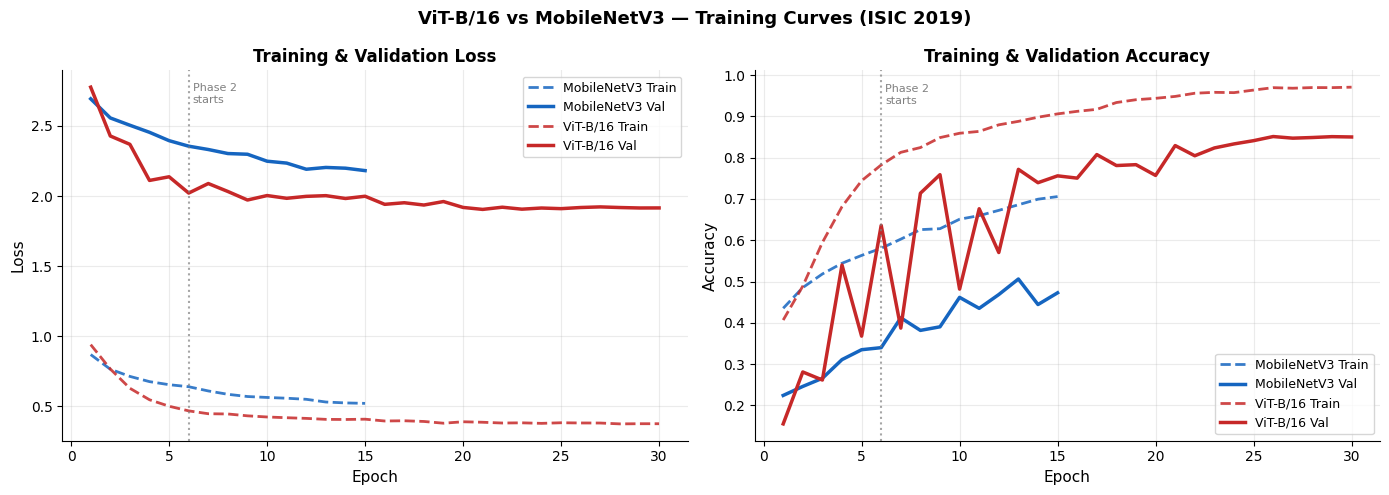

In [12]:
# Cell 12 — Training Curve Plots

# Generates plots to visualize the training and validation performance
# (loss and accuracy) of both the MobileNetV3 and ViT-B/16 models over epochs.
# It helps us understand how well each model learned and if there was any overfitting.
# The vertical gray line indicates where the second training phase (fine-tuning) began.

mob_ep = np.arange(1, len(mob_history['train_loss']) + 1)
vit_ep = np.arange(1, len(vit_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

for ax, key, ylabel in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.plot(mob_ep, mob_history[f'train_{key}'], '--', color='#1565C0', lw=2, label='MobileNetV3 Train', alpha=0.85)
    ax.plot(mob_ep, mob_history[f'val_{key}'],   '-',  color='#1565C0', lw=2.5, label='MobileNetV3 Val')
    ax.plot(vit_ep, vit_history[f'train_{key}'], '--', color='#C62828', lw=2, label='ViT-B/16 Train', alpha=0.85)
    ax.plot(vit_ep, vit_history[f'val_{key}'],   '-',  color='#C62828', lw=2.5, label='ViT-B/16 Val')
    ax.axvline(6, color='gray', linestyle=':', lw=1.5, alpha=0.7)
    ax.text(6.2, ax.get_ylim()[1] * 0.92, 'Phase 2\nstarts', fontsize=8, color='gray')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Training & Validation {ylabel}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('ViT-B/16 vs MobileNetV3 — Training Curves (ISIC 2019)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Cell 13 — Evaluation on Test Set

# Evaluates the trained models on the unseen test dataset to measure
# their real-world performance. A key technique used here is 'Test-Time Augmentation' (TTA).
# TTA involves running each test image through the model multiple times (N_TTA) with
# slight variations (like small rotations or flips) and then averaging the predictions.
# This makes the final prediction more robust and generally improves accuracy without
# needing to retrain the model.

N_TTA = 5  # number of TTA passes per image (1 = no TTA; increase for better accuracy at cost of speed)


def evaluate_with_tta(model, df, base_transform, augment_transform, n_tta=5):
    """Run TTA evaluation over a dataframe of images."""
    model.eval()
    all_probs  = []
    all_labels = []

    for idx in tqdm(range(len(df)), desc='TTA Eval'):
        row     = df.iloc[idx]
        img_pil = Image.open(row['image_path']).convert('RGB')
        label   = int(row['label'])

        probs_list = []
        with torch.no_grad():
            # Pass 1: clean base transform
            img_t = base_transform(img_pil).unsqueeze(0).to(DEVICE)
            probs_list.append(torch.softmax(model(img_t), dim=1).cpu().numpy())
            # Passes 2…N_TTA: random augmentations
            for _ in range(n_tta - 1):
                img_t = augment_transform(img_pil).unsqueeze(0).to(DEVICE)
                probs_list.append(torch.softmax(model(img_t), dim=1).cpu().numpy())

        avg_probs = np.mean(probs_list, axis=0)[0]  # average over TTA passes
        all_probs.append(avg_probs)
        all_labels.append(label)

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = all_probs.argmax(axis=1)
    raw_acc    = accuracy_score(all_labels, all_preds)
    return raw_acc, all_preds, all_labels, all_probs


print('Evaluating MobileNetV3-Large on test set (with TTA)...')
mob_acc_raw, mob_preds, mob_true, mob_probs = evaluate_with_tta(
    mobilenet, test_df, eval_transform, tta_transform, N_TTA
)
print(f'MobileNetV3 TTA Accuracy: {mob_acc_raw:.4f}')

print('Evaluating ViT-B/16 on test set (with TTA)...')
vit_acc_raw, vit_preds, vit_true, vit_probs = evaluate_with_tta(
    vit, test_df, eval_transform, tta_transform, N_TTA
)
print(f'ViT-B/16 TTA Accuracy: {vit_acc_raw:.4f}')
print('Done.')

Evaluating MobileNetV3-Large on test set (with TTA)...


TTA Eval: 100%|████████████████████████████████████████████████████████████████████| 3800/3800 [05:06<00:00, 12.42it/s]


MobileNetV3 TTA Accuracy: 0.5029
Evaluating ViT-B/16 on test set (with TTA)...


TTA Eval: 100%|████████████████████████████████████████████████████████████████████| 3800/3800 [04:30<00:00, 14.07it/s]

ViT-B/16 TTA Accuracy: 0.8263
Done.


In [15]:
# Cell 14 — Print All Metrics

# Compiles and displays a comprehensive set of performance metrics for both
# the MobileNetV3 and ViT-B/16 models on the test set. These metrics include accuracy,
# balanced accuracy, precision, recall, F1-score (macro and per-class), and AUC-ROC.
# It provides a detailed breakdown of how well each model performs across different
# evaluation criteria and for each individual class. 

import numpy as np

def print_all_metrics(model_name, preds, true, probs):
    print('\n' + '='*65)
    print(f'  RESULTS — {model_name}')
    print('='*65)

    acc     = accuracy_score(true, preds)
    bal_acc = balanced_accuracy_score(true, preds)
    mac_f1  = f1_score(true, preds, average='macro',    zero_division=0)
    wt_f1   = f1_score(true, preds, average='weighted', zero_division=0)
    mac_pr  = precision_score(true, preds, average='macro',    zero_division=0)
    mac_rc  = recall_score(true, preds,    average='macro',    zero_division=0)

    try:
        unique_true_labels = np.unique(true)
        if len(unique_true_labels) > 1:
            auc_score = roc_auc_score(true, probs, multi_class='ovr',
                                      average='macro', labels=list(unique_true_labels))
        else:
            auc_score = float('nan')
    except Exception as e:
        print(f'Warning: AUC-ROC error: {e}')
        auc_score = float('nan')

    print(f'  Accuracy          : {acc:.4f}   ({acc*100:.2f}%)')
    print(f'  Balanced Accuracy : {bal_acc:.4f}   ({bal_acc*100:.2f}%)')
    print(f'  Macro Precision   : {mac_pr:.4f}')
    print(f'  Macro Recall      : {mac_rc:.4f}')
    print(f'  Macro F1-Score    : {mac_f1:.4f}')
    print(f'  Weighted F1-Score : {wt_f1:.4f}')
    print(f'  AUC-ROC (macro)   : {auc_score:.4f}')

    per_f1 = f1_score(true, preds, average=None, zero_division=0)
    print(f'\n  Per-Class Report:')
    unique_labels_for_report = np.unique(true)
    present_target_names = [CLASS_FULL[i] for i in unique_labels_for_report]
    print(classification_report(true, preds, labels=unique_labels_for_report,
                                target_names=present_target_names, digits=4, zero_division=0))

    return {
        'accuracy': acc, 'balanced_accuracy': bal_acc,
        'macro_precision': mac_pr, 'macro_recall': mac_rc,
        'macro_f1': mac_f1, 'weighted_f1': wt_f1, 'auc_roc': auc_score,
        'per_class_f1': per_f1,
        'per_class_precision': precision_score(true, preds, average=None, zero_division=0),
        'per_class_recall':    recall_score(true, preds,    average=None, zero_division=0),
    }


mob_metrics = print_all_metrics('MobileNetV3-Large', mob_preds, mob_true, mob_probs)
vit_metrics = print_all_metrics('ViT-B/16',          vit_preds, vit_true, vit_probs)


  RESULTS — MobileNetV3-Large
  Accuracy          : 0.5029   (50.29%)
  Balanced Accuracy : 0.7167   (71.67%)
  Macro Precision   : 0.4359
  Macro Recall      : 0.7167
  Macro F1-Score    : 0.4462
  Weighted F1-Score : 0.5268
  AUC-ROC (macro)   : 0.9304

  Per-Class Report:
                         precision    recall  f1-score   support

               Melanoma     0.4930    0.6259    0.5516       679
       Melanocytic Nevi     0.9604    0.3387    0.5008      1931
   Basal Cell Carcinoma     0.7427    0.6593    0.6985       499
      Actinic Keratosis     0.2972    0.8846    0.4449       130
       Benign Keratosis     0.4003    0.6489    0.4951       393
         Dermatofibroma     0.1065    0.9167    0.1908        36
        Vascular Lesion     0.1226    1.0000    0.2184        38
Squamous Cell Carcinoma     0.3647    0.6596    0.4697        94

               accuracy                         0.5029      3800
              macro avg     0.4359    0.7167    0.4462      3800
      

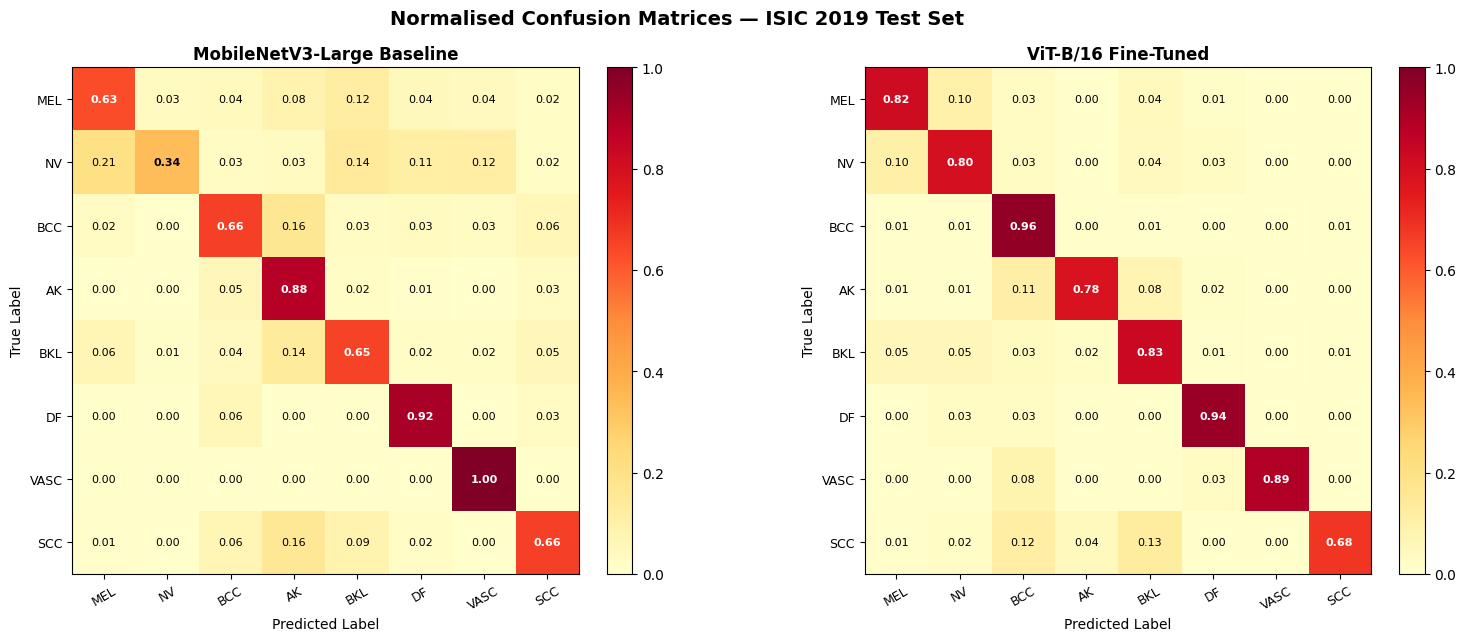

In [16]:
# Cell 15 — Confusion Matrices

# visualizes the confusion matrices for both the MobileNetV3 and ViT-B/16 models.
# performs for each class, showing not only correct predictions but also where the model
# is making mistakes (e.g., misclassifying one type of lesion as another).
# The values are normalized to show the proportion of true labels predicted as each class.

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), facecolor='white')

for ax, preds, true_labels, title in zip(
    axes,
    [mob_preds, vit_preds],
    [mob_true, vit_true],
    ['MobileNetV3-Large Baseline', 'ViT-B/16 Fine-Tuned']
):
    unique_labels_in_test = np.unique(true_labels)
    num_present_classes   = len(unique_labels_in_test)
    present_class_short   = [CLASS_NAMES[i] for i in unique_labels_in_test]

    cm      = confusion_matrix(true_labels, preds, labels=unique_labels_in_test)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='YlOrRd', vmin=0, vmax=1)
    for i in range(num_present_classes):
        for j in range(num_present_classes):
            v = cm_norm[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if v > 0.5 else 'black',
                    fontweight='bold' if i == j else 'normal')

    ax.set_xticks(range(num_present_classes))
    ax.set_yticks(range(num_present_classes))
    ax.set_xticklabels(present_class_short, fontsize=9, rotation=30)
    ax.set_yticklabels(present_class_short, fontsize=9)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Normalised Confusion Matrices — ISIC 2019 Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

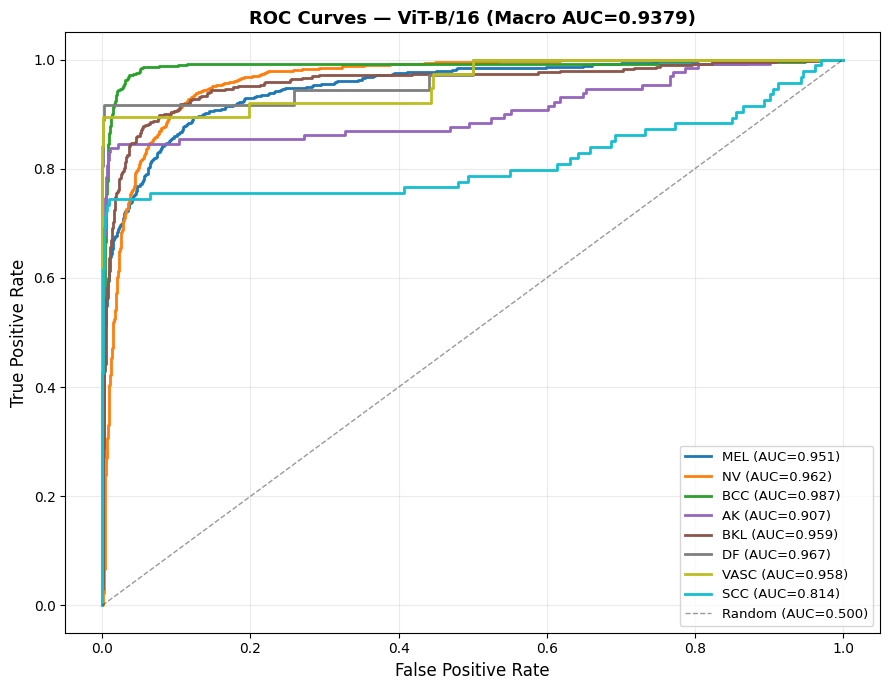

In [17]:
# Cell 16 — ROC Curves 
true_bin = label_binarize(vit_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')
colors_roc = plt.cm.get_cmap('tab10')(np.linspace(0, 1, NUM_CLASSES))
auc_scores = []

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(true_bin[:, i], vit_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1, label='Random (AUC=0.500)')
ax.set_title(f'ROC Curves — ViT-B/16 (Macro AUC={np.mean(auc_scores):.4f})', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=9.5, loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

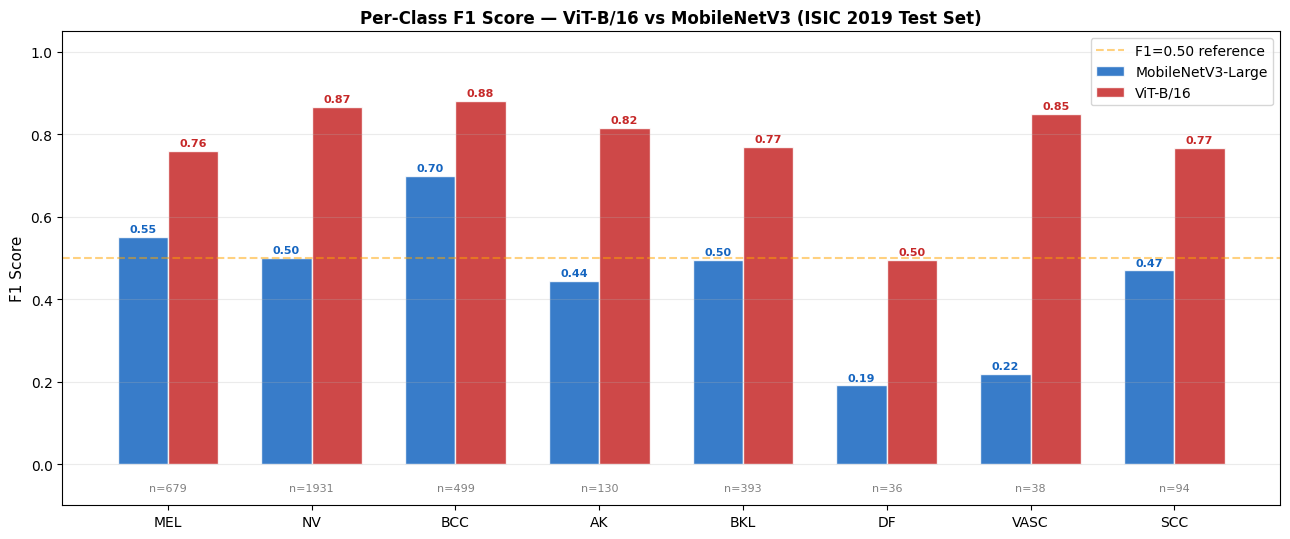

In [21]:
# Cell 17 — Per-Class F1 Comparison 
unique_labels_in_test     = np.unique(test_df['label'])
present_class_short_names = [CLASS_NAMES[i] for i in unique_labels_in_test]

mob_f1_per = f1_score(mob_true, mob_preds, average=None, zero_division=0, labels=unique_labels_in_test)
vit_f1_per = f1_score(vit_true, vit_preds, average=None, zero_division=0, labels=unique_labels_in_test)

x = np.arange(len(unique_labels_in_test))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5.5), facecolor='white')
ax.bar(x - width/2, mob_f1_per, width, color='#1565C0', alpha=0.85, label='MobileNetV3-Large', edgecolor='white')
ax.bar(x + width/2, vit_f1_per, width, color='#C62828', alpha=0.85, label='ViT-B/16', edgecolor='white')

for i, (m, v) in enumerate(zip(mob_f1_per, vit_f1_per)):
    ax.text(i - width/2, m + 0.012, f'{m:.2f}', ha='center', fontsize=8, color='#1565C0', fontweight='bold')
    ax.text(i + width/2, v + 0.012, f'{v:.2f}', ha='center', fontsize=8, color='#C62828', fontweight='bold')

test_counts = np.array([test_df['label'].value_counts().sort_index().get(lbl, 0) for lbl in unique_labels_in_test])
for i, n in enumerate(test_counts):
    ax.text(i, -0.065, f'n={n}', ha='center', fontsize=8, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(present_class_short_names, fontsize=10)
ax.set_ylim(-0.10, 1.05)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Per-Class F1 Score — ViT-B/16 vs MobileNetV3 (ISIC 2019 Test Set)', fontsize=12, fontweight='bold')
ax.axhline(0.5, color='orange', linestyle='--', alpha=0.5, lw=1.5, label='F1=0.50 reference')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Cell 18 — Summary Results Table (unchanged)
summary = pd.DataFrame({
    'Model'            : ['MobileNetV3-Large', 'ViT-B/16'],
    'Parameters (M)'   : [5.5, 86.6],
    'Accuracy'         : [round(mob_metrics['accuracy'],         4), round(vit_metrics['accuracy'],         4)],
    'Balanced Accuracy': [round(mob_metrics['balanced_accuracy'],4), round(vit_metrics['balanced_accuracy'],4)],
    'Macro Precision'  : [round(mob_metrics['macro_precision'],  4), round(vit_metrics['macro_precision'],  4)],
    'Macro Recall'     : [round(mob_metrics['macro_recall'],     4), round(vit_metrics['macro_recall'],     4)],
    'Macro F1'         : [round(mob_metrics['macro_f1'],         4), round(vit_metrics['macro_f1'],         4)],
    'Weighted F1'      : [round(mob_metrics['weighted_f1'],      4), round(vit_metrics['weighted_f1'],      4)],
    'AUC-ROC (macro)'  : [round(mob_metrics['auc_roc'],          4), round(vit_metrics['auc_roc'],          4)],
})

print('\n===== FINAL COMPARISON RESULTS (with TTA) =====')
print(summary.to_string(index=False))
summary.to_csv('model_comparison_results.csv', index=False)
print('\nSaved: model_comparison_results.csv')


===== FINAL COMPARISON RESULTS (with TTA) =====
            Model  Parameters (M)  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1  AUC-ROC (macro)
MobileNetV3-Large             5.5    0.5029             0.7167           0.4359        0.7167    0.4462       0.5268           0.9304
         ViT-B/16            86.6    0.8263             0.8393           0.7571        0.8393    0.7757       0.8312           0.9379

Saved: model_comparison_results.csv


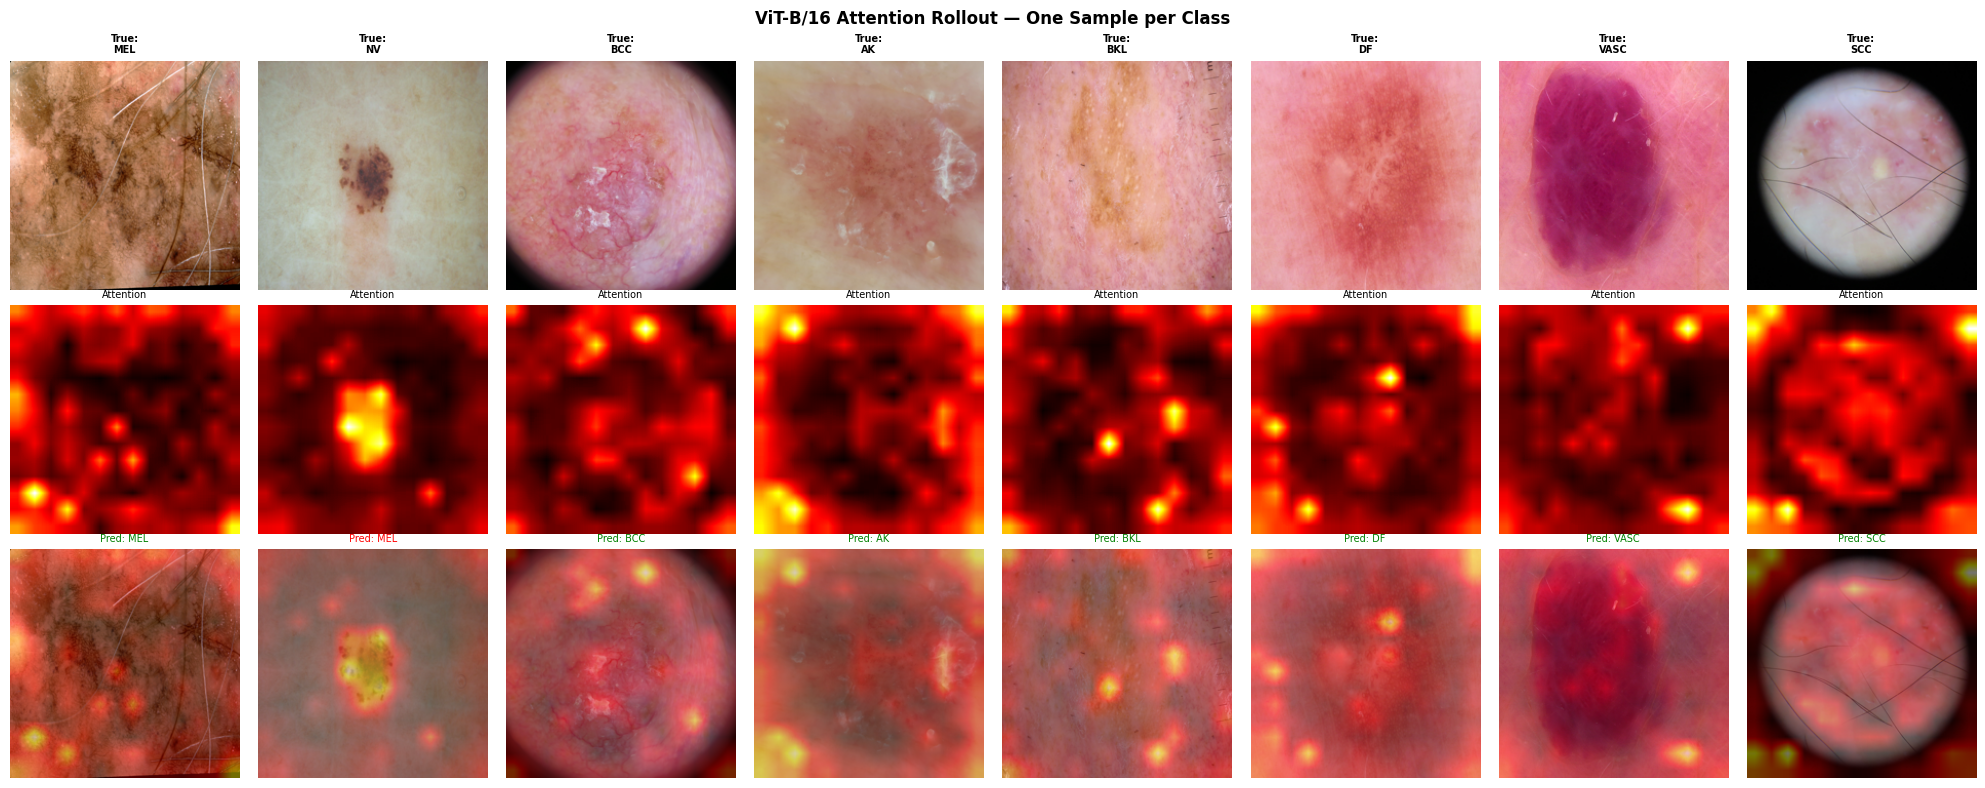

In [23]:
# Cell 19 — ViT Attention Maps
import types
_original_attn_forward = None

def compute_attention_rollout(model, img_tensor):
    global _original_attn_forward
    attentions = []

    def patched_attention_forward(self, x, attn_mask=None, is_causal=False):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        self._cached_attn = attn
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

    if _original_attn_forward is None:
        _original_attn_forward = timm.models.vision_transformer.Attention.forward

    for block in model.blocks:
        block.attn.forward = types.MethodType(patched_attention_forward, block.attn)

    with torch.no_grad():
        model(img_tensor.unsqueeze(0).to(DEVICE))

    for block in model.blocks:
        if hasattr(block.attn, '_cached_attn'):
            attentions.append(block.attn._cached_attn.detach().cpu())
            del block.attn._cached_attn
        block.attn.forward = types.MethodType(_original_attn_forward, block.attn)

    rollout = torch.eye(attentions[0].shape[-1])
    for attn in attentions:
        attn_mean = attn.mean(dim=1).squeeze(0)
        attn_mean = attn_mean + torch.eye(attn_mean.shape[0])
        attn_mean = attn_mean / attn_mean.sum(dim=-1, keepdim=True)
        rollout   = attn_mean @ rollout

    cls_attn = rollout[0, 1:]
    grid     = int(cls_attn.shape[0] ** 0.5)
    attn_map = cls_attn.reshape(grid, grid).numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    return attn_map


unique_labels_in_test = np.unique(test_df['label'])
num_present_classes   = len(unique_labels_in_test)

fig, axes = plt.subplots(3, num_present_classes, figsize=(2.5 * num_present_classes, 8), facecolor='white')
if num_present_classes == 1:
    axes = axes[:, np.newaxis]

sample_idx = [test_df[test_df['label'] == cls_i].index[0] for cls_i in unique_labels_in_test]

for col, idx in enumerate(sample_idx):
    row_data   = test_df.iloc[idx]
    img_pil    = Image.open(row_data['image_path']).convert('RGB')
    img_tensor = eval_transform(img_pil)
    attn_map   = compute_attention_rollout(vit, img_tensor)

    attn_up = np.array(
        Image.fromarray((attn_map * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    ) / 255.0

    true_cls = CLASS_NAMES[int(row_data['label'])]
    pred_cls = CLASS_NAMES[vit_preds[idx]]
    correct  = true_cls == pred_cls

    axes[0, col].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    axes[0, col].set_title(f'True:\n{true_cls}', fontsize=7, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(attn_up, cmap='hot')
    axes[1, col].set_title('Attention', fontsize=7)
    axes[1, col].axis('off')

    img_arr = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    overlay = img_arr * 0.55 + plt.cm.hot(attn_up)[:, :, :3] * 0.45
    axes[2, col].imshow(overlay)
    axes[2, col].set_title(f'Pred: {pred_cls}', fontsize=7, color='green' if correct else 'red')
    axes[2, col].axis('off')

if num_present_classes > 0:
    axes[0, 0].set_ylabel('Original',      fontsize=9, fontweight='bold')
    axes[1, 0].set_ylabel('Attention Map', fontsize=9, fontweight='bold')
    axes[2, 0].set_ylabel('Overlay',       fontsize=9, fontweight='bold')

plt.suptitle('ViT-B/16 Attention Rollout — One Sample per Class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()